In [1]:
import pandas as pd
import numpy as np
%matplotlib inline
from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    r"C:\Users\Seerat\Downloads\311_Service_Requests_from_2020_to_Present.csv",
    low_memory=False
)

In [3]:
df = df.sample(100000, random_state=42)

In [11]:
df.head()

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
74221,66501226,10/16/2025 12:05:35 PM,10/16/2025 01:10:44 PM,NYPD,New York City Police Department,Encampment,NaN,NaN,Residential Building/House,10474.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.816989,-73.885825,POINT (-73.885824907136 40.81698943475)
166954,66630197,10/27/2025 02:53:16 PM,10/27/2025 03:48:17 PM,NYPD,New York City Police Department,Illegal Parking,Double Parked Blocking Traffic,NaN,Street/Sidewalk,10309.0,...,Car,NaN,NaN,NaN,NaN,NaN,NaN,40.524457,-74.215283,POINT (-74.215283119791 40.52445712074)
180976,66653060,10/30/2025 12:14:57 AM,10/30/2025 05:39:08 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,NaN,Street/Sidewalk,10472.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.830520,-73.855918,POINT (-73.855917791053 40.830520347746)
126428,66572522,10/22/2025 04:57:00 PM,10/24/2025 01:40:00 PM,DEP,Department of Environmental Protection,Water System,Dirty Water (WE),WE,NaN,10453.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.853160,-73.919279,POINT (-73.919278860776 40.853160079805)
185515,66663910,10/30/2025 04:46:11 PM,10/31/2025 08:42:34 AM,DPR,Department of Parks and Recreation,Damaged Tree,Entire Tree Has Fallen Down,Blocking Street,Street,10306.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.573994,-74.097461,POINT (-74.09746050353 40.573994034492)


In [12]:
df.shape
df.columns
df.info()
df.size

<class 'pandas.DataFrame'>
Index: 100000 entries, 74221 to 108723
Data columns (total 44 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unique Key                            100000 non-null  str    
 1   Created Date                          99998 non-null   str    
 2   Closed Date                           97076 non-null   str    
 3   Agency                                99998 non-null   str    
 4   Agency Name                           99998 non-null   str    
 5   Problem (formerly Complaint Type)     99998 non-null   str    
 6   Problem Detail (formerly Descriptor)  97427 non-null   str    
 7   Additional Details                    24942 non-null   str    
 8   Location Type                         86704 non-null   str    
 9   Incident Zip                          98994 non-null   float64
 10  Incident Address                      96233 non-null   str    
 11  Street Name 

4400000

In [13]:
df.nunique

<bound method DataFrame.nunique of        Unique Key            Created Date             Closed Date Agency  \
74221    66501226  10/16/2025 12:05:35 PM  10/16/2025 01:10:44 PM   NYPD   
166954   66630197  10/27/2025 02:53:16 PM  10/27/2025 03:48:17 PM   NYPD   
180976   66653060  10/30/2025 12:14:57 AM  10/30/2025 05:39:08 AM   NYPD   
126428   66572522  10/22/2025 04:57:00 PM  10/24/2025 01:40:00 PM    DEP   
185515   66663910  10/30/2025 04:46:11 PM  10/31/2025 08:42:34 AM    DPR   
...           ...                     ...                     ...    ...   
134879   66588697  10/23/2025 10:48:49 PM  10/24/2025 11:26:59 AM   NYPD   
94219    66535635  10/19/2025 02:20:53 PM  10/19/2025 04:58:39 PM   NYPD   
103706   66540123  10/19/2025 07:15:17 PM  10/19/2025 11:01:53 PM   NYPD   
148661   66610267  10/26/2025 12:43:40 AM  10/26/2025 01:21:53 AM   NYPD   
108723   66551476  10/20/2025 12:32:44 PM  10/20/2025 12:54:34 PM   NYPD   

                                   Agency Name  \
74

In [8]:
df.describe(include='all')

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Vehicle Type,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location
count,266007,266003,258376,266003,266003,266003,259237,66422,230546,263247.000000,...,13660,210,3618,1905,882,686,1902,262526.000000,262526.000000,262526
unique,266007,238910,215195,15,15,188,803,650,112,NaN,...,6,5,2349,58,139,100,289,NaN,NaN,117754
top,66401717,10/30/2025 03:47:00 PM,11/03/2025 12:00:00 AM,NYPD,New York City Police Department,Illegal Parking,Loud Music/Party,NO HEAT,Street/Sidewalk,NaN,...,Car,MANHATTAN,"JOHN F KENNEDY AIRPORT, QUEENS (JAMAICA) ,NY, ...",F,1 Downtown,Roadway,Platform,NaN,NaN,POINT (-73.860168452965 40.891872416493)
freq,1,48,305,162630,162630,53857,48493,3404,102490,NaN,...,8270,77,446,193,53,339,554,NaN,NaN,16322
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10824.422102,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.737619,-73.921032,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,576.457950,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.088724,0.079161,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7502.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.498949,-74.253733,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10452.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.675387,-73.972275,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11203.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.730831,-73.924549,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11236.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.810073,-73.861964,NaN


#**Phase 1:**

In [4]:
df['Created Date']=pd.to_datetime(df['Created Date'])
df['Closed Date']=pd.to_datetime(df['Closed Date'])

#creating a new feature for resolution time 
df['resolution_time_days']= (
    df['Closed Date']-df['Created Date']
    ).dt.total_seconds() / (24*60*60)


C:\Users\Seerat\AppData\Local\Temp\ipykernel_13768\3211874617.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Closed Date']=pd.to_datetime(df['Closed Date'])


In [5]:
df.loc[
    df['Closed Date'].dt.date < df['Created Date'].dt.date,
    'Closed Date'
    ] = pd.NaT

In [18]:
#creating a new DataFrame
open_tickets = df[
    (df['Closed Date'].isna()) & (df['Status']=='Open')
]
closed_nodate=df[
    (df['Closed Date'].isna()) & (df['Status']=='Closed')
]
open_tickets


,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location,resolution_time_days
46789,66465721,2025-10-13 17:05:55,NaT,HPD,Department of Housing Preservation and Develop...,UNSANITARY CONDITION,PESTS,BED BUGS,RESIDENTIAL BUILDING,10009.0,...,NaN,NaN,NaN,NaN,NaN,NaN,40.731457,-73.976796,POINT (-73.976795957974 40.731457217905),NaN
221595,66715414,2025-11-03 11:34:42,NaT,DSNY,Department of Sanitation,Graffiti,Graffiti,NaN,NaN,10467.0,...,NaN,NaN,NaN,NaN,NaN,NaN,40.858210,-73.865618,POINT (-73.865618401069 40.85820971493),NaN
187143,66660974,2025-10-30 15:40:44,NaT,DSNY,Department of Sanitation,Graffiti,Graffiti,NaN,Mixed Use,10011.0,...,NaN,NaN,NaN,NaN,NaN,NaN,40.737797,-74.001830,POINT (-74.00182950841 40.73779717741),NaN
138214,66592052,2025-10-24 11:52:00,NaT,DEP,Department of Environmental Protection,Plant,Plants- Noise Related Problems (PN1),PN1,NaN,11231.0,...,NaN,NaN,NaN,NaN,NaN,NaN,40.681996,-74.002618,POINT (-74.002617577275 40.681996136588),NaN
250842,66754364,2025-11-07 08:36:09,NaT,DSNY,Department of Sanitation,Graffiti,Graffiti,NaN,Residential,11238.0,...,NaN,NaN,NaN,NaN,NaN,NaN,40.685840,-73.959389,POINT (-73.959389155191 40.685839915228),NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231937,66732795,2025-11-05 11:52:44,NaT,DSNY,Department of Sanitation,Graffiti,Graffiti,NaN,Comercial,11229.0,...,NaN,NaN,NaN,NaN,NaN,NaN,40.600898,-73.937535,POINT (-73.937535331483 40.600898233423),NaN
72955,66503904,2025-10-16 16:13:42,NaT,HPD,Department of Housing Preservation and Develop...,GENERAL,COOKING GAS,SHUT-OFF,RESIDENTIAL BUILDING,11213.0,...,NaN,NaN,NaN,NaN,NaN,NaN,40.670840,-73.935458,POINT (-73.935458307609 40.67083976777),NaN
10765,66420726,2025-10-09 16:05:00,NaT,DEP,Department of Environmental Protection,Water System,Possible Water Main Break (Use Comments) (WA1),WA1,NaN,10022.0,...,NaN,NaN,NaN,NaN,NaN,NaN,40.757422,-73.964875,POINT (-73.964875360845 40.757422279065),NaN
234993,66728366,2025-11-05 12:07:28,NaT,DSNY,Department of Sanitation,Graffiti,Graffiti,NaN,Mixed Use,11229.0,...,NaN,NaN,NaN,NaN,NaN,NaN,40.598463,-73.959680,POINT (-73.959679963987 40.598462521285),NaN


In [19]:
closed_nodate

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Problem (formerly Complaint Type),Problem Detail (formerly Descriptor),Additional Details,Location Type,Incident Zip,...,Taxi Company Borough,Taxi Pick Up Location,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Latitude,Longitude,Location,resolution_time_days
101554,63204957,2024-11-25 10:14:46,NaT,DHS,Department of Homeless Services,Homeless Person Assistance,NaN,NaN,Subway,NaN,...,NaN,NaN,F,NaN,NaN,Mezzanine,40.754020,-73.983267,POINT (-73.983266929684 40.754020189556),NaN
106433,63210800,2024-11-25 19:08:46,NaT,DHS,Department of Homeless Services,Homeless Person Assistance,NaN,NaN,Subway,NaN,...,NaN,NaN,1,1 Downtown,NaN,Platform,40.799445,-73.968382,POINT (-73.96838195488 40.799445207055),NaN
62477,63144502,2024-11-19 05:16:28,NaT,DHS,Department of Homeless Services,Homeless Person Assistance,NaN,NaN,Subway,NaN,...,NaN,NaN,R,NaN,NaN,Mezzanine,40.742452,-73.882019,POINT (-73.882019101405 40.742452245538),NaN
62304,63224667,2024-11-27 14:45:12,NaT,DHS,Department of Homeless Services,Homeless Person Assistance,NaN,NaN,Subway,NaN,...,NaN,NaN,E,NaN,NaN,Other,40.721690,-73.844522,POINT (-73.844522071362 40.721690289294),NaN
87083,63224666,2024-11-27 06:23:05,NaT,DHS,Department of Homeless Services,Homeless Person Assistance,NaN,NaN,Subway,NaN,...,NaN,NaN,6,6 Downtown,NaN,Platform,40.795020,-73.944251,POINT (-73.944251345341 40.79501979397),NaN
141507,66598475,2025-10-23 18:16:00,NaT,DSNY,Department of Sanitation,Derelict Vehicles,Derelict Vehicles,NaN,Street,11105.0,...,NaN,NaN,NaN,NaN,NaN,NaN,40.780348,-73.898240,POINT (-73.898240305081 40.78034794498),NaN
65840,63152281,2024-11-20 08:41:19,NaT,DHS,Department of Homeless Services,Homeless Person Assistance,NaN,NaN,Subway,NaN,...,NaN,NaN,F,NaN,NaN,Stairway,40.754020,-73.983267,POINT (-73.983266929684 40.754020189556),NaN
146870,66608479,2025-10-23 22:48:00,NaT,DSNY,Department of Sanitation,Derelict Vehicles,Derelict Vehicles,NaN,Street,10466.0,...,NaN,NaN,NaN,NaN,NaN,NaN,40.882027,-73.846726,POINT (-73.846725560554 40.88202661414),NaN
63999,63155934,2024-11-20 08:40:01,NaT,DHS,Department of Homeless Services,Homeless Person Assistance,NaN,NaN,Subway,NaN,...,NaN,NaN,Q,NaN,NaN,Other,40.777891,-73.951790,POINT (-73.951790324717 40.777890569286),NaN
197331,63344490,2024-12-09 09:25:47,NaT,DHS,Department of Homeless Services,Homeless Person Assistance,NaN,NaN,Subway,NaN,...,NaN,NaN,F,NaN,NaN,Platform,40.718462,-73.987778,POINT (-73.987777955856 40.718462481372),NaN


In [20]:
df[df['Closed Date'].isna()]['Status'].value_counts()

Status
In Progress    2525
Open            159
Pending         132
Assigned         73
Started          36
Closed           11
Name: count, dtype: int64

In [7]:
#Time Feature Extraction
df['hour']=df['Created Date'].dt.hour
df['day_name']=df['Created Date'].dt.day_name()
df['month']=df['Created Date'].dt.month
df['year']=df['Created Date'].dt.year

In [23]:
#Group by agency (e.g., NYPD, DSNY, DOT) and complaint_type (the "Problem" field). Find the top 10 most common volume drivers across the city.
df.groupby(['Agency','Problem (formerly Complaint Type)']).size()

Agency  Problem (formerly Complaint Type)
DCWP    Consumer Complaint                   562
DEP     Air Quality                          231
        Asbestos                              45
        Hazardous Materials                   57
        Industrial Waste                      39
                                            ... 
TLC     Green Taxi Report                      2
        Lost Property                        250
        Taxi Complaint                       342
        Taxi Compliment                        5
        Taxi Report                           24
Length: 172, dtype: int64

In [24]:
top10= (
    df.groupby(['Agency','Problem (formerly Complaint Type)']).size().sort_values(ascending=False).head(10) # top 10
    )
print(top10)

Agency  Problem (formerly Complaint Type)
NYPD    Illegal Parking                      20245
        Noise - Residential                  18353
        Blocked Driveway                      6223
        Noise - Street/Sidewalk               5778
        Noise - Commercial                    2386
DEP     Noise                                 2201
NYPD    Abandoned Vehicle                     2079
DEP     Water System                          1963
DOT     Street Condition                      1889
DSNY    Dirty Condition                       1835
dtype: int64


In [25]:
#Cardinality Check: Examine descriptor (the "Problem Detail" field). Check for high cardinality (hundreds of unique string variations) and determine if typos or slight variations are treating identical issues as separate categories.
df['Problem Detail (formerly Descriptor)'].nunique()

702

In [26]:
df['Problem Detail (formerly Descriptor)'].str.lower().str.strip().nunique()

695

In [27]:
df['Problem Detail (formerly Descriptor)'].value_counts().head(10)

Problem Detail (formerly Descriptor)
Loud Music/Party                 18167
Blocked Hydrant                   5620
Banging/Pounding                  5102
Posted Parking Sign Violation     4759
No Access                         4598
Loud Talking                      3294
Blocked Sidewalk                  2813
With License Plate                2079
Trash                             2030
Partial Access                    1625
Name: count, dtype: int64

In [28]:
#Missing Locations: Check the missing percentage of incident_zip or borough. If geographic data is missing, can it be imputed or inferred using the agency or street_name?
(df[['Incident Zip', 'Borough']]).isna().mean()*100

Incident Zip    1.006
Borough         0.002
dtype: float64

In [29]:
df.groupby('Incident Zip')['Borough'].nunique().sort_values() #check each incident_zip, if it matches with borough

Incident Zip
10000.0    1
10001.0    1
10002.0    1
10003.0    1
10004.0    1
          ..
11697.0    1
44146.0    1
10463.0    2
11208.0    3
11237.0    3
Name: Borough, Length: 216, dtype: int64

In [30]:
df.groupby('Street Name')['Borough'].nunique().sort_values()

Street Name
WORTMAN AVENUE         1
104 STREET             1
104 ROAD               1
104 AVENUE             1
103 STREET             1
                      ..
METROPOLITAN AVENUE    4
PARK AVENUE            4
3 AVENUE               4
PINE STREET            4
BROADWAY               5
Name: Borough, Length: 5641, dtype: int64

In [31]:
df.groupby('Agency')['Borough'].nunique()

Agency
DCWP     6
DEP      6
DHS      5
DOB      6
DOE      5
DOHMH    6
DOT      6
DPR      5
DSNY     6
EDC      5
HPD      5
NYPD     6
OOS      5
OTI      1
TLC      6
Name: Borough, dtype: int64

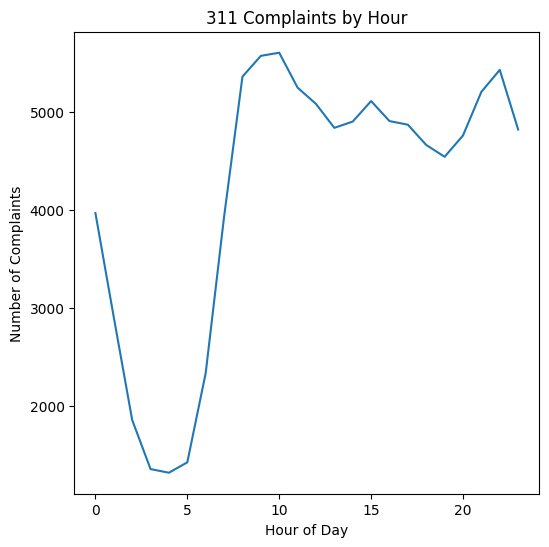

In [33]:
hourly=df.groupby(df['Created Date'].dt.hour).size()
hourly.plot(kind='line', figsize=(6,6))
plt.xlabel('Hour of Day')
plt.ylabel('Number of Complaints')
plt.title('311 Complaints by Hour')
plt.show()

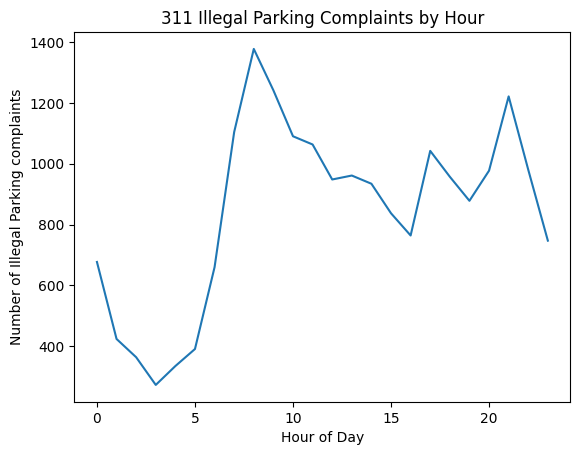

In [34]:
df[df['Problem (formerly Complaint Type)']=='Illegal Parking'].groupby(df['Created Date'].dt.hour).size() \
           .plot()
plt.xlabel('Hour of Day')
plt.ylabel('Number of Illegal Parking complaints')
plt.title('311 Illegal Parking Complaints by Hour')
plt.show()

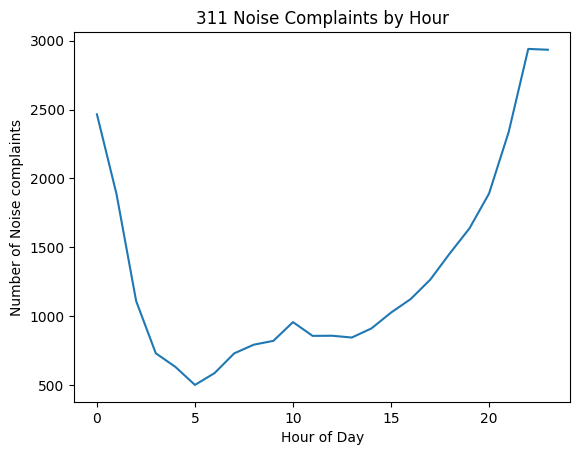

In [35]:
df[df['Problem (formerly Complaint Type)'].str.contains('Noise')] .groupby(df['Created Date'].dt.hour).size().plot()
plt.xlabel('Hour of Day')
plt.ylabel('Number of Noise complaints')
plt.title('311 Noise Complaints by Hour')
plt.show()

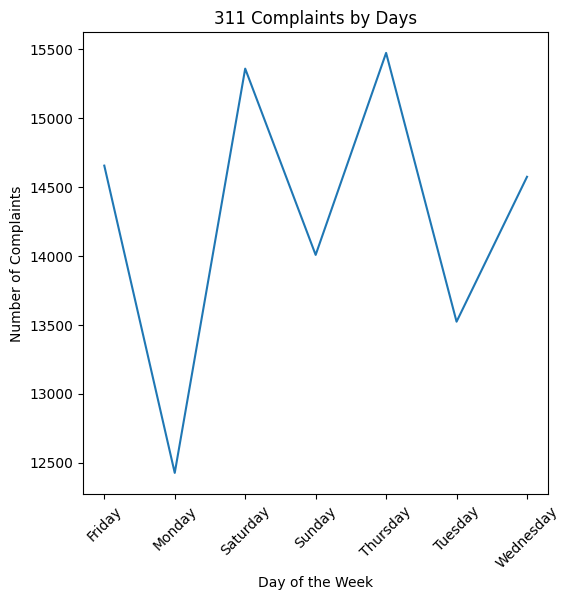

In [36]:
day=df.groupby(df['Created Date'].dt.day_name()).size()
day.plot(kind='line', figsize=(6,6))
plt.xlabel('Day of the Week')
plt.xticks(range(len(day.index)), day.index, rotation=45)
plt.ylabel('Number of Complaints')
plt.title('311 Complaints by Days')
plt.show()

In [37]:
#borough hotspots
df['Borough'].value_counts()

Borough
BROOKLYN         29521
QUEENS           25684
BRONX            20556
MANHATTAN        20247
STATEN ISLAND     3933
Unspecified         57
Name: count, dtype: int64

In [38]:
#agency workload analysis
df.groupby('Agency').size().sort_values(ascending=False)

Agency
NYPD     61085
DSNY      9529
DEP       7044
DOT       6394
DPR       3983
HPD       3121
DOB       2437
DHS       2003
DOHMH     1560
TLC       1375
EDC        741
DCWP       562
OOS        125
DOE         35
OTI          4
dtype: int64

In [39]:
pd.crosstab(df['Agency'], df['Status'])

Status,Assigned,Closed,In Progress,Open,Pending,Started,Unspecified
Agency,,,,,,,
DCWP,0,561,1,0,0,0,0
DEP,11,6972,0,25,0,36,0
DHS,0,2003,0,0,0,0,0
DOB,24,2334,0,79,0,0,0
DOE,0,35,0,0,0,0,0
DOHMH,0,1429,131,0,0,0,0
DOT,87,6169,6,0,132,0,0
DPR,0,3144,838,0,0,0,1
DSNY,0,9348,67,114,0,0,0


In [40]:
pd.crosstab(df['Borough'], df['Problem (formerly Complaint Type)'])

Problem (formerly Complaint Type),APPLIANCE,Abandoned Bike,Abandoned Vehicle,Air Quality,Animal Facility - No Permit,Animal in a Park,Animal-Abuse,Asbestos,BEST/Site Safety,Beach/Pool/Sauna Complaint,...,Violation of Park Rules,WATER LEAK,Water Conservation,Water Leak,Water Maintenance,Water Quality,Water System,Wayfinding,Window Guard,Wood Pile Remaining
Borough,,,,,,,,,,,,,,,,,,,,,
BRONX,24,3,271,16,0,17,92,3,2,0,...,18,40,15,0,0,4,242,1,0,1
BROOKLYN,16,43,608,62,3,75,124,11,4,0,...,19,39,22,1,0,8,379,0,0,17
MANHATTAN,11,15,107,75,1,63,60,23,0,1,...,46,20,13,1,0,12,763,0,0,1
QUEENS,8,9,929,61,0,16,63,7,1,0,...,19,14,23,0,0,11,407,1,1,26
STATEN ISLAND,0,0,164,16,0,4,25,1,1,1,...,5,0,4,0,1,2,172,0,0,7
Unspecified,0,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [41]:
#Borough-Level SLA Analysis: Calculate the median resolution time (resolution_time_days) across the 5 boroughs.
#The Critical Question: Is one borough getting its issues fixed significantly slower than another for the same exact type of complaint?
df['resolution_time_hours'] = (
    df['Closed Date'] - df['Created Date']
).dt.total_seconds() / 3600
df.groupby('Borough')['resolution_time_hours'].median().sort_values()
#earlier used .days, which gave all 0.0 values

Borough
BRONX             1.620833
MANHATTAN         1.906667
QUEENS            2.326389
BROOKLYN          2.650000
STATEN ISLAND     6.676111
Unspecified      41.847500
Name: resolution_time_hours, dtype: float64

In [42]:
noise = df[df['Problem (formerly Complaint Type)'] == 'Noise - Residential']

noise.groupby('Borough')['resolution_time_hours'].median()

Borough
BRONX            0.838056
BROOKLYN         1.005000
MANHATTAN        0.838056
QUEENS           1.164306
STATEN ISLAND    1.184861
Name: resolution_time_hours, dtype: float64

In [43]:
rats = df[df['Problem (formerly Complaint Type)'].str.contains('Rodent')]
rats.groupby('Incident Zip').size().sort_values(ascending=False)
#or
#df[df['complaint_type'].str.contains('Rodent', na=False)] \
    #.groupby('incident_zip') \
    #.size() \
    #.sort_values(ascending=False)

Incident Zip
11226.0    28
11216.0    23
11233.0    20
10024.0    19
11230.0    17
           ..
11361.0     1
11417.0     1
11413.0     1
11420.0     1
11694.0     1
Length: 143, dtype: int64

#**Phase 2:**

In [9]:
#Create Time of Day category
def get_time_period(hour):
    if 6 <= hour < 12:
        return 'Morning'
    elif 12<= hour < 18:
        return 'Afternoon'
    elif 18<= hour < 24:
        return 'Evening'
    else:
        return 'Night'
df['time_of_day'] = df['Created Date'].dt.hour.apply(get_time_period)

In [10]:
#Create Weekend vs Weekday column
#####vectorized IF-ELSE for an entire column
df['Weekend_Weekday'] = np.where(         #no need for loop cuz np works on whole column at once
    df['Created Date'].dt.dayofweek >= 5, # df['Created Date'].dt.day_name().isin(['Saturday','Sunday'])-- use loop
    'Weekend',
    'Weekday'
)

In [12]:
#Heatmap 1: Complaint Type vs Time of Day
#Create Pivot Table
heatmap_data = pd.pivot_table(
    df,
    index='Problem (formerly Complaint Type)',
    columns='time_of_day',
    values='Unique Key',
    aggfunc='count',
    fill_value=0
)

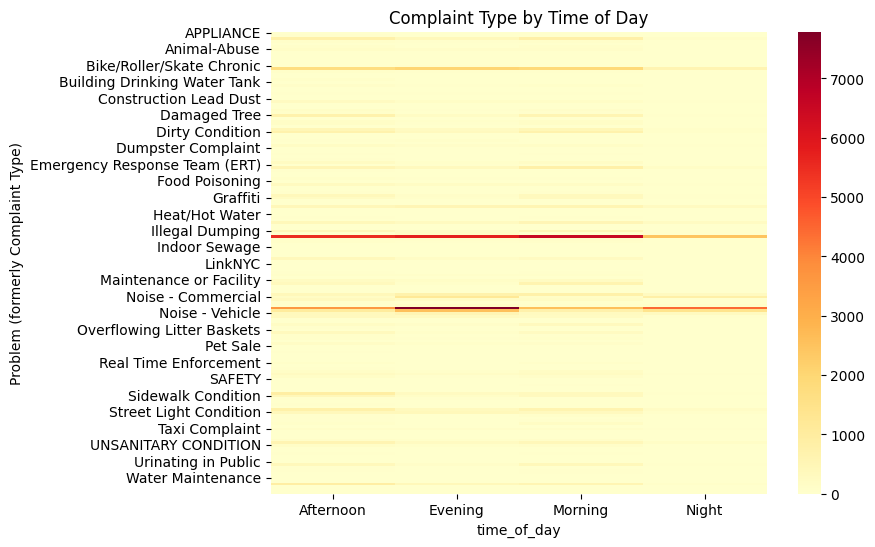

In [13]:
#Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    heatmap_data, cmap='YlOrRd'
)
plt.title('Complaint Type by Time of Day')
plt.show()

In [16]:
#Heatmap 2: Complaint Type vs Day of Week
#Pivot Table
df['day_of_week'] = df['Created Date'].dt.day_name()
heatmap_day = pd.pivot_table(
    df,
    index='Problem (formerly Complaint Type)',
    columns='day_of_week',
    values='Unique Key',
    aggfunc='count',
    fill_value=0
)

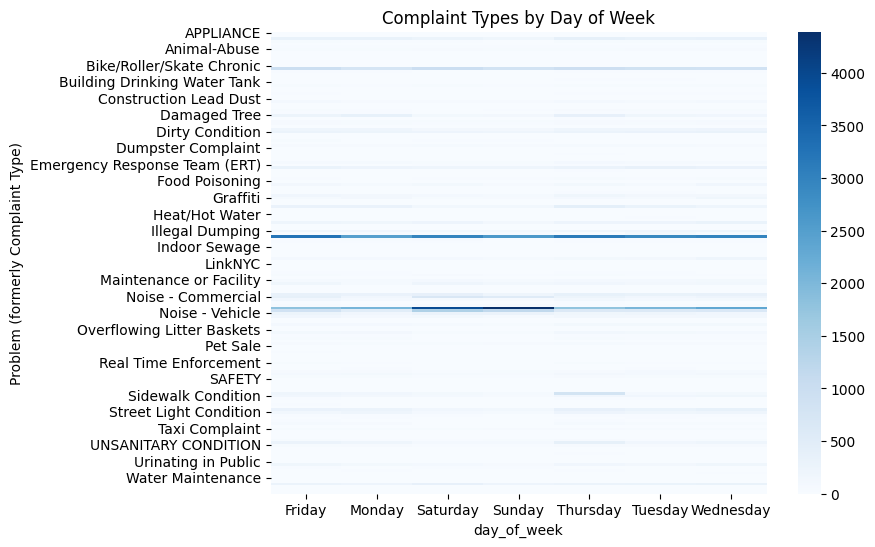

In [17]:
#Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(
    heatmap_day, cmap='Blues'
)
plt.title('Complaint Types by Day of Week')
plt.show()

In [20]:
bottleneck = df.groupby( ['Agency','Problem (formerly Complaint Type)'] ) ['resolution_time_days'].agg(
    median_days='median',
    P90_days=lambda x: x.quantile(0.90)
).reset_index()
bottleneck['gap']=(
    bottleneck['P90_days']-bottleneck['median_days']
)
bottleneck.sort_values('gap', ascending=False).head(30)

,Agency,Problem (formerly Complaint Type),median_days,P90_days,gap
25,DOB,Plumbing,6.297286,149.961622,143.664336
62,DOT,Bridge Condition,24.515880,164.383160,139.867280
38,DOHMH,Food Poisoning,1.500012,137.192159,135.692147
163,TLC,For Hire Vehicle Complaint,35.758796,170.796627,135.037831
18,DOB,Building/Use,7.519780,132.327749,124.807969
127,HPD,GENERAL,11.098154,126.079700,114.981546
123,HPD,DOOR/WINDOW,12.412894,124.865347,112.452454
21,DOB,Elevator,5.395718,113.377549,107.981831
29,DOE,School Maintenance,4.752361,104.534644,99.782282
170,TLC,Taxi Compliment,56.056354,137.017322,80.960968


In [22]:
df[df['Problem (formerly Complaint Type)'] == 'Pothole'].groupby('Incident Zip')['resolution_time_days']

In [24]:
grouped = df.groupby('Agency')['resolution_time_days'].median()
print(grouped)

Agency
DCWP      4.122002
DEP       1.082292
DHS       0.319878
DOB       3.571551
DOE       4.752361
DOHMH     0.816053
DOT       2.685353
DPR       2.966377
DSNY      1.282280
EDC            NaN
HPD       2.035868
NYPD      0.047616
OOS      41.267234
OTI       9.657083
TLC      24.182054
Name: resolution_time_days, dtype: float64


<Axes: xlabel='Agency', ylabel='resolution_time_days'>

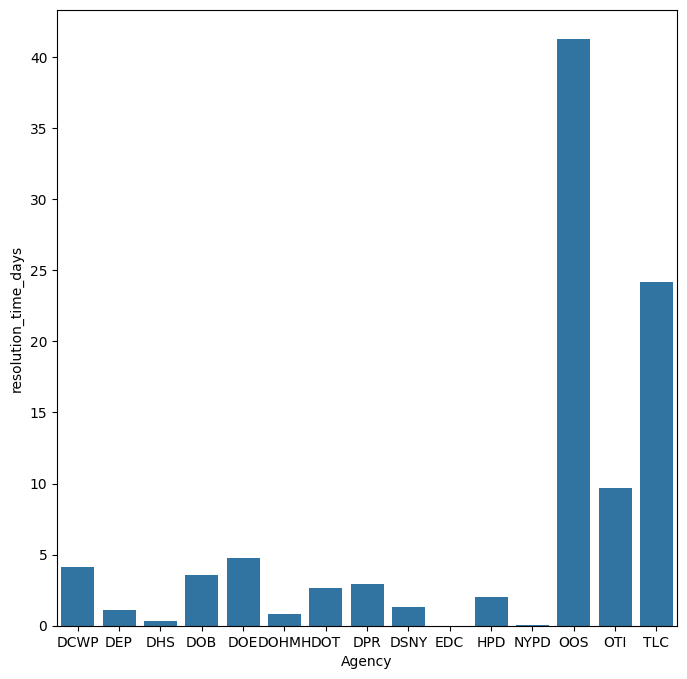

In [10]:
plt.figure(figsize=(8,8))
grouped = (
    df.groupby('Agency')['resolution_time_days']
      .median()
      .reset_index()
)

sns.barplot(
    data=grouped,
    x='Agency',
    y='resolution_time_days'
)

**1. ###Agency Efficiency Analysis###**
Goal: Find agencies that are slow relative to the amount of work they handle.

In [12]:
agency_efficiency= (
    df.groupby('Agency').agg(
        total_tickets=('Unique Key', 'count'),
        avg_resolution_days=('resolution_time_days','mean')
    )
    .reset_index()
)
agency_efficiency=agency_efficiency.sort_values(by='avg_resolution_days',ascending=False)
agency_efficiency.head(12)

,Agency,total_tickets,avg_resolution_days
14,TLC,1375,55.505260
12,OOS,125,39.128659
4,DOE,35,26.913886
3,DOB,2437,19.000005
7,DPR,3983,18.959234
5,DOHMH,1560,14.666238
0,DCWP,562,13.547353
10,HPD,3121,10.772852
13,OTI,4,10.275130
6,DOT,6394,7.113267


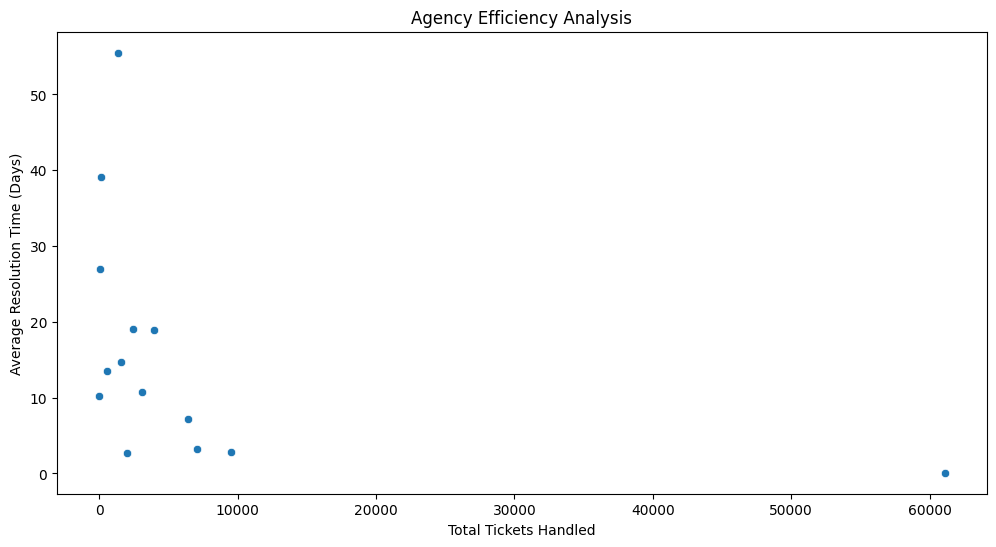

In [13]:
plt.figure(figsize=(12,6))
sns.scatterplot(
    data=agency_efficiency,
    x='total_tickets',
    y='avg_resolution_days'
)
plt.title('Agency Efficiency Analysis')
plt.xlabel('Total Tickets Handled')
plt.ylabel('Average Resolution Time (Days)')
plt.show()

**4. Priority Matrix**
Goal: Identify complaint types that deserve the most attention.

In [14]:
#create Summary Table
priority_df=(
    df.groupby('Problem (formerly Complaint Type)').agg(
        total_tickets=('Unique Key', 'count'),
        avg_resolution_days=('resolution_time_days','mean')
    ).reset_index()
)

In [16]:
#create Rankings
priority_df['volume_rank']=(
    priority_df['total_tickets'].rank(ascending=False)
)
priority_df['delay_rank']=(
    priority_df['avg_resolution_days'].rank(ascending=False)
)

In [20]:
#create Priority Score
priority_df['priority_score'] = (
    priority_df['volume_rank']
    +
    priority_df['delay_rank']
)
#Sort
priority_df=priority_df.sort_values('priority_score').head(10)
priority_df.head(12)

,Problem (formerly Complaint Type),total_tickets,avg_resolution_days,volume_rank,delay_rank,priority_score
55,For Hire Vehicle Complaint,724,84.480482,28.0,7.0,35.0
144,Taxi Complaint,342,135.660976,41.0,3.0,44.0
125,Root/Sewer/Sidewalk Condition,285,119.167090,46.0,5.0,51.0
90,Maintenance or Facility,623,25.585120,33.0,29.0,62.0
47,Elevator,483,23.721667,35.0,31.0,66.0
33,Dead/Dying Tree,318,27.932787,43.0,24.0,67.0
53,Food Establishment,191,50.994521,55.0,15.0,70.0
19,Building/Use,244,36.293076,50.0,21.0,71.0
59,General Construction/Plumbing,910,15.840238,24.0,47.0,71.0
150,UNSANITARY CONDITION,320,24.228980,42.0,30.0,72.0


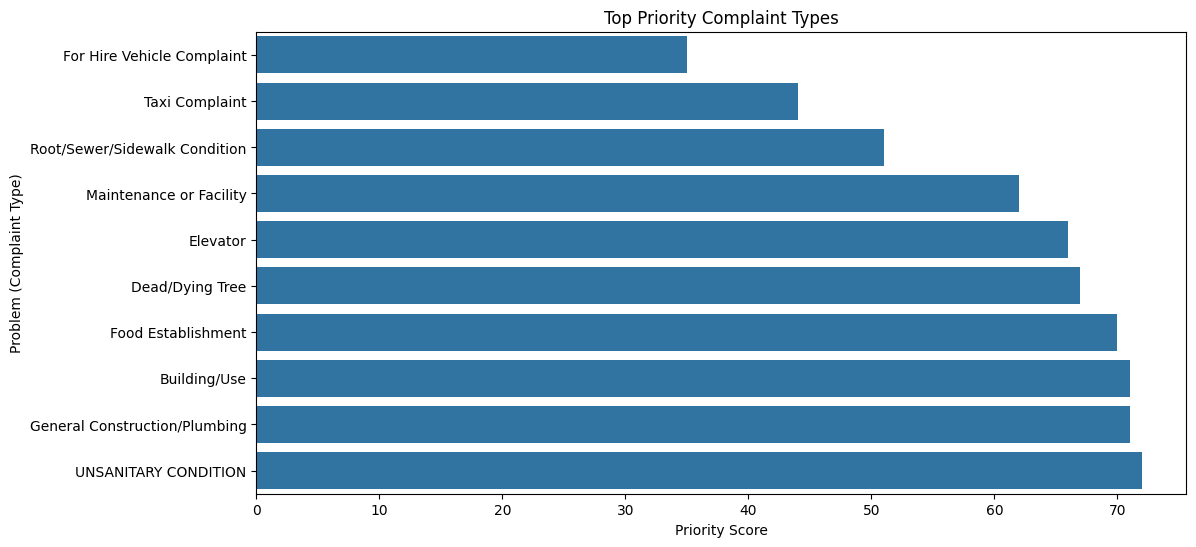

In [21]:
top_priority=priority_df.head(12)
plt.figure(figsize=(12,6))
sns.barplot(
    data=top_priority,
    x='priority_score',
y='Problem (formerly Complaint Type)'
)
plt.title('Top Priority Complaint Types')
plt.xlabel('Priority Score')
plt.ylabel('Problem (Complaint Type)')
plt.show()

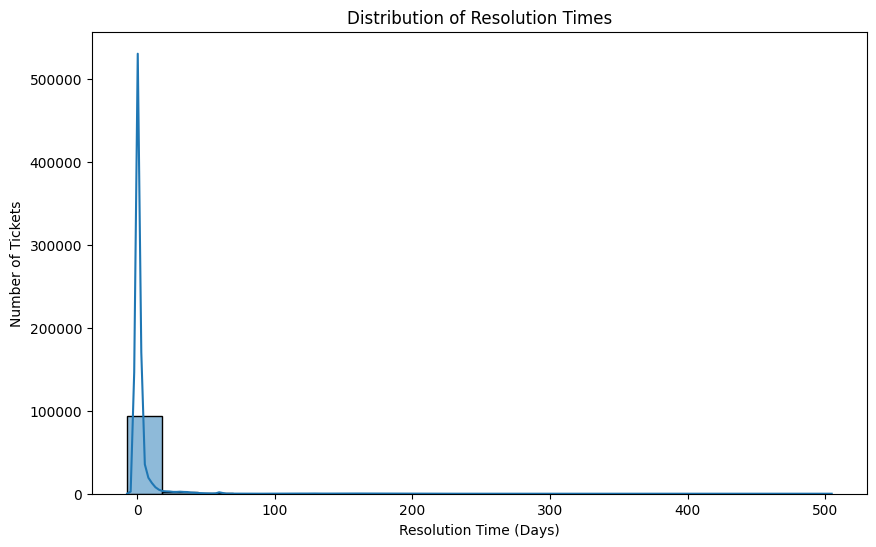

In [27]:
#How are resolution times distributed? uses Histogram
plt.figure(figsize=(10,6))
sns.histplot(
    data=df,
    x='resolution_time_days',
    bins=20,
    kde=True
)
plt.title('Distribution of Resolution Times')
plt.xlabel('Resolution Time (Days)')
plt.ylabel('Number of Tickets')
plt.show()